# Lab 2 — Signal Space, Linear Modulation and Optimal Detection

**Companion to Chapter 2.** Objectives:

1. Build PSK and QAM constellations, normalize them, and read off $d_{\min}$.
2. Verify that minimum-distance detection is ML in AWGN and visualize decision regions.
3. Measure SER/BER by Monte Carlo and match closed-form expressions.
4. Quantify the value of Gray labelling and compute soft bit LLRs for decoders.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider
import commlib as cl

cl.style()
rng = np.random.default_rng(2)

## 1. A constellation gallery
All constellations are scaled to unit average energy $E_s = 1$. The minimum
distance $d_{\min}$ determines high-SNR error probability; the peak-to-average
power ratio (PAPR) determines how hard the power amplifier must be backed off.

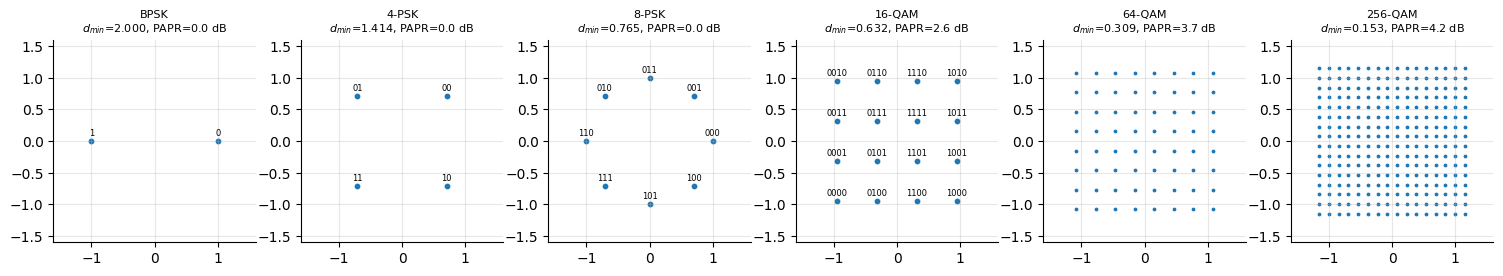

In [3]:
names = ["bpsk", "qpsk", "8psk", "16qam", "64qam", "256qam"]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
for ax, nm in zip(axes, names):
    c = cl.get_constellation(nm)
    ax.scatter(c.points.real, c.points.imag, s=10 if c.M < 64 else 3)
    if c.M <= 16:
        for p, lab in zip(c.points, c.labels):
            ax.annotate(format(lab, f"0{c.k}b"), (p.real, p.imag), fontsize=6,
                        textcoords="offset points", xytext=(0, 4), ha="center")
    papr = 10 * np.log10(np.max(np.abs(c.points) ** 2))
    ax.set_title(f"{c.name}\n$d_{{min}}$={c.dmin:.3f}, PAPR={papr:.1f} dB", fontsize=8)
    ax.set_aspect("equal"); ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
plt.tight_layout(); plt.show()

## 2. Decision regions of the ML detector
In AWGN with equiprobable symbols the MAP rule reduces to choosing the nearest
constellation point, so the decision regions are Voronoi cells. We colour a
grid by the detected symbol.

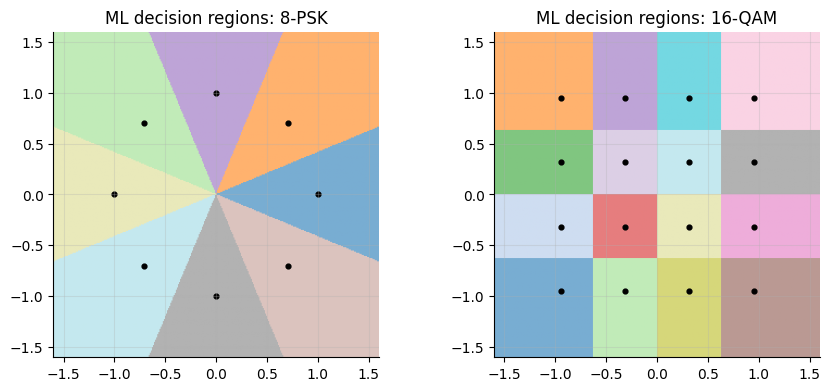

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, nm in zip(axes, ["8psk", "16qam"]):
    c = cl.get_constellation(nm)
    g = np.linspace(-1.6, 1.6, 300)
    X, Y = np.meshgrid(g, g)
    idx = c.nearest((X + 1j * Y).ravel()).reshape(X.shape)
    ax.imshow(idx, extent=[-1.6, 1.6, -1.6, 1.6], origin="lower", cmap="tab20", alpha=0.6)
    ax.scatter(c.points.real, c.points.imag, c="k", s=12)
    ax.set_title(f"ML decision regions: {c.name}")
plt.tight_layout(); plt.show()

## 3. Monte Carlo BER versus theory
The course convention: $E_s/N_0 = E_b/N_0 + 10\log_{10}(k)$ for $k$ bits/symbol.
Closed forms used here:

* BPSK/QPSK (Gray): $P_b = Q(\sqrt{2E_b/N_0})$
* Square $M$-QAM (Gray, nearest-neighbour): $P_b \approx \frac{4}{k}\left(1-\frac{1}{\sqrt M}\right) Q\!\left(\sqrt{\frac{3E_s}{(M-1)N_0}}\right)$
* $M$-PSK: $P_s \approx 2Q(\sqrt{2E_s/N_0}\sin(\pi/M))$, and $P_b \approx P_s/k$ with Gray labels.

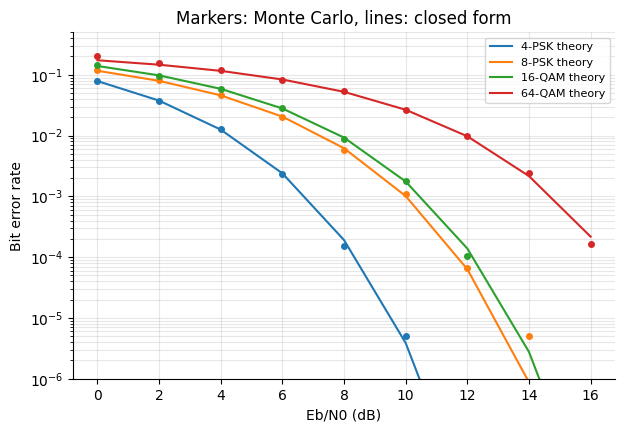

In [7]:
def mc_ber(c, ebn0_db, nbits=200_000):
    bits = cl.random_bits(nbits // c.k * c.k, rng)
    y, _ = cl.awgn_esn0(c.modulate(bits), cl.ebn0_to_esn0(ebn0_db, c.k), rng=rng)
    return np.mean(c.demodulate(y) != bits)

eb = np.arange(0, 17, 2)
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, nm in enumerate(["qpsk", "8psk", "16qam", "64qam"]):
    c = cl.get_constellation(nm)
    sim = [mc_ber(c, e) for e in eb]
    es = cl.ebn0_to_esn0(eb, c.k)
    th = cl.ber_bpsk(eb) if c.M == 4 else (cl.ser_mpsk(es, c.M) / c.k if "PSK" in c.name
                                            else cl.ber_mqam_gray(es, c.M))
    ax.semilogy(eb, th, f"C{i}-", label=f"{c.name} theory")
    ax.semilogy(eb, np.maximum(sim, 1e-7), f"C{i}o", ms=4)
cl.ber_axes(ax); ax.set_ylim(1e-6, 0.5); ax.legend(fontsize=8)
ax.set_title("Markers: Monte Carlo, lines: closed form"); plt.show()

### Interactive: constellation, noise and error rate
Choose a constellation and $E_b/N_0$. The panel reports measured BER, SER and
EVM, and the theoretical BER. EVM (RMS error vector over RMS reference) is the
metric used in 3GPP and 802.11 conformance tests: at high SNR,
$\mathrm{EVM}_{\mathrm{dB}} \approx -E_s/N_0$.

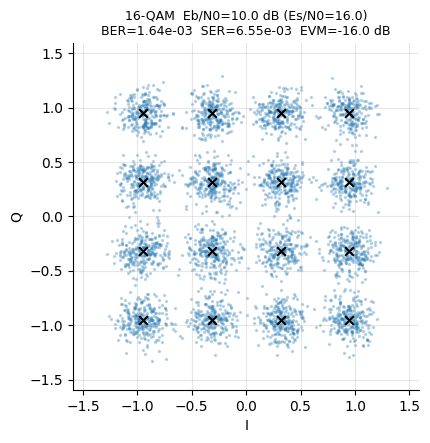

In [9]:
def explore(mod="16qam", ebn0_db=10.0):
    c = cl.get_constellation(mod)
    bits = cl.random_bits(c.k * 20_000, rng)
    s = c.modulate(bits)
    esn0 = cl.ebn0_to_esn0(ebn0_db, c.k)
    y, n0 = cl.awgn_esn0(s, esn0, rng=rng)
    ber = np.mean(c.demodulate(y) != bits)
    ser = np.mean(c.decide(y) != s)
    evm = 10 * np.log10(np.mean(np.abs(y - s) ** 2))
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    cl.plot_constellation(ax, y[:4000], c.points, s=2, alpha=0.25)
    ax.set_title(f"{c.name}  Eb/N0={ebn0_db:.1f} dB (Es/N0={esn0:.1f})\n"
                 f"BER={ber:.2e}  SER={ser:.2e}  EVM={evm:.1f} dB", fontsize=9)
    plt.show()

interact(explore, mod=Dropdown(options=["bpsk", "qpsk", "8psk", "16psk", "16qam", "64qam", "256qam", "1024qam"],
                               value="16qam"),
         ebn0_db=FloatSlider(value=10, min=-2, max=30, step=0.5, description="Eb/N0 dB"));

## 4. Why Gray labelling matters
With Gray labels, adjacent points differ in one bit, so a symbol error usually
costs one bit error. With natural binary labels it can cost several.

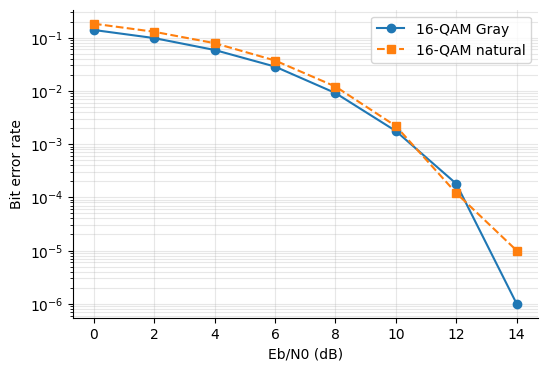

In [11]:
c_gray = cl.get_constellation("16qam")
# Natural labels: same points, labels = row-major integer index
L = 4; lev = np.arange(-3, 4, 2)
I, Q = np.meshgrid(np.arange(L), np.arange(L), indexing="ij")
c_nat = cl.Constellation((lev[I] + 1j * lev[Q]).ravel(), (I * L + Q).ravel(), "16-QAM natural")
eb = np.arange(0, 15, 2)
fig, ax = plt.subplots(figsize=(6, 4))
for c, st in [(c_gray, "o-"), (c_nat, "s--")]:
    ax.semilogy(eb, [max(mc_ber(c, e, 100_000), 1e-6) for e in eb], st, label=c.name if c is c_nat else "16-QAM Gray")
cl.ber_axes(ax); ax.legend(); plt.show()

## 5. Soft information: bit LLRs
Modern decoders (LDPC, polar, turbo) consume log-likelihood ratios, not hard
bits. For bit $b_i$ of a symbol,
$\mathrm{LLR}_i = \log\frac{\sum_{a:b_i=0} e^{-|y-a|^2/N_0}}{\sum_{a:b_i=1} e^{-|y-a|^2/N_0}}$,
and the max-log approximation keeps only the nearest point in each set.
Below: the LLR of the first (in-phase MSB) and second bit of 16-QAM along the I axis.

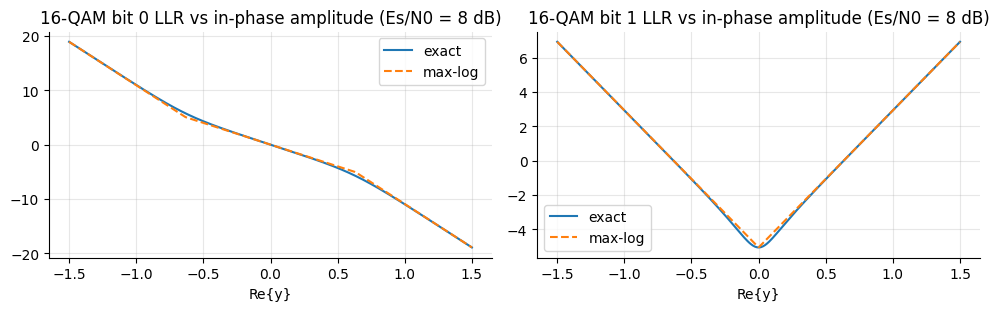

In [13]:
c = cl.get_constellation("16qam")
x = np.linspace(-1.5, 1.5, 400)
n0 = 10 ** (-8 / 10)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for b in range(2):
    ex = c.llr(x + 0j, n0, exact=True).reshape(-1, 4)[:, b]
    ml = c.llr(x + 0j, n0, exact=False).reshape(-1, 4)[:, b]
    ax[b].plot(x, ex, label="exact"); ax[b].plot(x, ml, "--", label="max-log")
    ax[b].set_title(f"16-QAM bit {b} LLR vs in-phase amplitude (Es/N0 = 8 dB)")
    ax[b].set_xlabel("Re{y}"); ax[b].legend()
plt.tight_layout(); plt.show()

## Exercises

1. **(Warm-up)** Derive $d_{\min}$ for unit-energy square $M$-QAM,
   $d_{\min} = \sqrt{6/(M-1)}$, and check it against the gallery.
2. **(Core)** Compute the union bound on SER for 8-PSK and compare it with the
   Monte Carlo curve. Where does it become tight?
3. **(Core)** At what $E_b/N_0$ do 8-PSK and 16-QAM reach BER $10^{-5}$? Explain
   why 16-QAM wins even though it carries more bits per symbol.
4. **(Stretch)** Implement APSK-16 (4+12 rings, as in DVB-S2), optimize the ring
   ratio for BER at $E_s/N_0 = 12$ dB, and compare its PAPR with 16-QAM.